In [15]:
import sys,os
from pathlib import Path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
import importlib
import os
from scipy.stats import linregress
import matplotlib.pyplot as plt

import books
import functions1 as f1
import functions2 as f2
import config



## Interpreting Slope and t-stat Results


### 1. **Price Slope and t-stat**
- **Price Slope:** Measures the average change in price per time step.  
  A positive value indicates an upward trend; negative means downward.
- **Price Slope t-stat:** Indicates statistical significance of the price trend.  
  - **t-stat > 2** (or < -2): Strong evidence of a persistent trend.
  - **t-stat near 0:** No significant trend.

### 2. **Log Returns Slope and t-stat**
- **Log Returns Slope:** Measures the average drift in daily returns.  
  Positive means returns tend to be positive over time; negative means the opposite.
- **Log Returns Slope t-stat:** Indicates whether the drift in returns is statistically significant.
  - **t-stat > 2** (or < -2): Evidence of time series momentum (TSMOM).
  - **t-stat near 0:** No persistent momentum in returns.

### 3. **Typical Interpretation**
- **Strong price slope, weak returns slope:** Price may trend due to a few large moves, not persistent daily returns.
- **Significant returns slope:** Indicates TSMOM, which is useful for momentum strategies.
- **Non-significant returns slope:** No actionable momentum signal.

**In summary:**  
- Use the price slope/t-stat to assess overall price direction.
- Use the returns slope/t-stat to evaluate time series momentum.
- For momentum strategies, focus on significant positive t-stat in returns.

sort_cols: ohlc not set. True only needd for ATR calculations for vol stops. Defaulting to False
total return 0.06
EMIM.LSE 2025-9-4 2025-9-19
Price Slope: 15.870629370629372
Price Slope StdErr: 0.9251182662465913
Price Slope t-stat: 17.155243766853737
EMIM.LSE 2025-9-4 2025-9-19
rets Slope: -0.0004378878379940836
rest Slope StdErr: 0.00023066125693991773
rets Slope t-stat: -1.8984022015805797


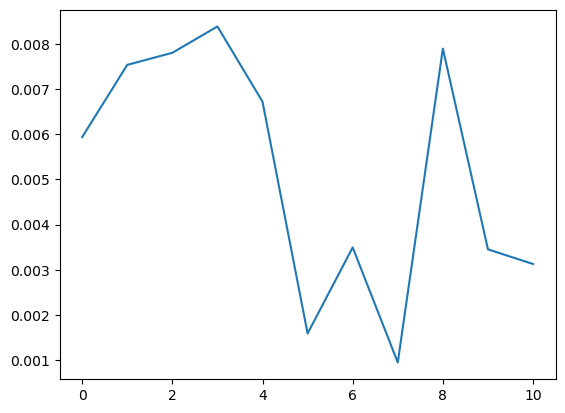

In [16]:

ticker='EMIM.LSE'
start='2025-9-4'
end='2025-9-19'
s =f1.fetch_csv_robust(ticker, params=config.params)
s=f1.sort_cols(s)
s=f2.trim_series(s, start, end)
x_rets = np.log(s / s.shift(1)).dropna()

total_return=(s.iloc[-1]/s.iloc[0])-1
# slope=(s.iloc[-1]-s.iloc[0])/lens
print('total return',round(total_return, 2))
# print('slope',slope)

k=np.arange(len(s.values))
result1=linregress(k,s.values)
slope1=result1.slope
stderr1=result1.stderr
t_stat1=slope1/stderr1
print(ticker, start, end)
print('Price Slope:',slope1)
print('Price Slope StdErr:',stderr1)
print('Price Slope t-stat:',t_stat1)


print(ticker, start, end )
# for returns
x = np.arange(len(x_rets.values))

result = linregress(x, x_rets.values)
slope = result.slope
stderr = result.stderr
t_stat = slope / stderr

print("rets Slope:", slope)
print("rest Slope StdErr:", stderr)
print("rets Slope t-stat:", t_stat)
# print(x)
plt.plot(x, x_rets.values)
plt.show()
